# Import

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from xgboost import XGBClassifier

import joblib
from pathlib import Path

from industrial_predictive_maintenance.data import load_data
from industrial_predictive_maintenance.features import create_features
from industrial_predictive_maintenance.preprocessing import (
    split_features_target,
    split_data,
    build_preprocessor,
    fit_preprocessor,
    transform_data, 
)
from industrial_predictive_maintenance.model import save_model

# Load Data

In [83]:
df = load_data(Path("../data/raw/ai4i2020Raw.csv"))

In [84]:
df.head()

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


# Feature engineering

In [85]:
df.head()

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [86]:
df = create_features(df)

# Data Split

In [26]:
X, y = split_features_target(df)

In [27]:
X.head()

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,temperature_difference,power
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0


In [28]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: machine_failure, dtype: int64

In [29]:
X_train, X_test, y_train, y_test = split_data(X, y)
X_train, X_val, y_train, y_val = split_data(X_train, y_train, test_size=0.1765) # ≈15% of the original data 

# Transform

In [30]:
# Encode
encoder = build_preprocessor()

fit_preprocessor(encoder, X_train)

X_train = transform_data(encoder, X_train)
X_val = transform_data(encoder, X_val)
X_test = transform_data(encoder, X_test)


scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
X_val_s = scaler.transform(X_val)

In [31]:
X_train.head()

,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,temperature_difference,power
2364,0.0,299.2,308.5,1366,49.7,74,9.3,67890.2
4473,0.0,302.7,310.5,1551,35.9,6,7.8,55680.9
9491,1.0,299.0,309.7,1489,40.7,212,10.7,60602.3
2646,1.0,299.8,309.5,1453,43.2,153,9.7,62769.6
5942,0.0,300.7,310.7,1450,43.4,80,10.0,62930.0


# Model

Logistic Regression, Decision Tree, Random Forest, and XGBoost were selected to compare linear and tree-based approaches. Model performance was assessed using Precision, Recall, F1-score, and ROC-AUC due to the imbalanced nature of the dataset.

In [32]:
def evaluate_model(model, X_train, y_train, X_val, y_val):
    y_pred = model.predict(X_train)
    print("train data")
    print("------------------")
    print(confusion_matrix(y_train, y_pred))
    print(classification_report(y_train, y_pred))
    y_pred = model.predict(X_val)
    print("---------------------------------------------------------\n")
    print("test data")
    print("------------------")
    print(confusion_matrix(y_val, y_pred))
    print(classification_report(y_val, y_pred))
    y_prob = model.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, y_prob)
    print("---------------------------------------------------------")
    print(f"ROC-AUC: {roc_auc}")
    p_s = precision_score(y_val, y_pred)
    r_s = recall_score(y_val, y_pred)
    f1_s = f1_score(y_val, y_pred)
    return p_s, r_s, f1_s, roc_auc 

## Logistic regression

In [33]:
model = LogisticRegression(random_state=101)

model.fit(X_train_s, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",101
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solv

In [34]:
p_s, r_s, f1_s, roc_auc = evaluate_model(model, X_train_s, y_train, X_val_s, y_val)

train data
------------------
[[6740   22]
 [ 177   60]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      6762
           1       0.73      0.25      0.38       237

    accuracy                           0.97      6999
   macro avg       0.85      0.62      0.68      6999
weighted avg       0.97      0.97      0.96      6999

---------------------------------------------------------

test data
------------------
[[1444    6]
 [  39   12]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1450
           1       0.67      0.24      0.35        51

    accuracy                           0.97      1501
   macro avg       0.82      0.62      0.67      1501
weighted avg       0.96      0.97      0.96      1501

---------------------------------------------------------
ROC-AUC: 0.9099121027721433


In [35]:
df_result = pd.DataFrame({"model":["Logistic Regression"], "precision":[p_s], "recall":[r_s], "f1_score":[f1_s], "roc_auc":[roc_auc]})

In [36]:
df_result.head()

,model,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.666667,0.235294,0.347826,0.909912


## Decision tree

In [37]:
model = DecisionTreeClassifier(random_state=101)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",101
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [38]:
p_s, r_s, f1_s, roc_auc = evaluate_model(model, X_train, y_train, X_val, y_val)

train data
------------------
[[6762    0]
 [   0  237]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6762
           1       1.00      1.00      1.00       237

    accuracy                           1.00      6999
   macro avg       1.00      1.00      1.00      6999
weighted avg       1.00      1.00      1.00      6999

---------------------------------------------------------

test data
------------------
[[1435   15]
 [  12   39]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1450
           1       0.72      0.76      0.74        51

    accuracy                           0.98      1501
   macro avg       0.86      0.88      0.87      1501
weighted avg       0.98      0.98      0.98      1501

---------------------------------------------------------
ROC-AUC: 0.8771805273833672


In [39]:
df_result = pd.concat([df_result, pd.DataFrame({"model":["Decision Tree"], "precision":[p_s], "recall":[r_s], "f1_score":[f1_s], "roc_auc":[roc_auc]})], ignore_index=True)

## Random forest

In [40]:
model = RandomForestClassifier(random_state=101)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",101
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

In [41]:
p_s, r_s, f1_s, roc_auc = evaluate_model(model, X_train, y_train, X_val, y_val)

train data
------------------
[[6762    0]
 [   0  237]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6762
           1       1.00      1.00      1.00       237

    accuracy                           1.00      6999
   macro avg       1.00      1.00      1.00      6999
weighted avg       1.00      1.00      1.00      6999

---------------------------------------------------------

test data
------------------
[[1449    1]
 [  15   36]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1450
           1       0.97      0.71      0.82        51

    accuracy                           0.99      1501
   macro avg       0.98      0.85      0.91      1501
weighted avg       0.99      0.99      0.99      1501

---------------------------------------------------------
ROC-AUC: 0.9672210953346858


In [42]:
df_result = pd.concat([df_result, pd.DataFrame({"model":["Random Forest"], "precision":[p_s], "recall":[r_s], "f1_score":[f1_s], "roc_auc":[roc_auc]})], ignore_index=True)

## Xgboost

In [43]:
model = XGBClassifier(random_state=101)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [44]:
p_s, r_s, f1_s, roc_auc = evaluate_model(model, X_train, y_train, X_val, y_val)

train data
------------------
[[6762    0]
 [   0  237]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6762
           1       1.00      1.00      1.00       237

    accuracy                           1.00      6999
   macro avg       1.00      1.00      1.00      6999
weighted avg       1.00      1.00      1.00      6999

---------------------------------------------------------

test data
------------------
[[1443    7]
 [  15   36]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1450
           1       0.84      0.71      0.77        51

    accuracy                           0.99      1501
   macro avg       0.91      0.85      0.88      1501
weighted avg       0.98      0.99      0.98      1501

---------------------------------------------------------
ROC-AUC: 0.9791751183231914


In [45]:
df_result = pd.concat([df_result, pd.DataFrame({"model":["XGBoost"], "precision":[p_s], "recall":[r_s], "f1_score":[f1_s], "roc_auc":[roc_auc]})], ignore_index=True)

## Model comparison

In [46]:
df_result = df_result.round(3)

In [47]:
print(df_result)

                 model  precision  recall  f1_score  roc_auc
0  Logistic Regression      0.667   0.235     0.348    0.910
1        Decision Tree      0.722   0.765     0.743    0.877
2        Random Forest      0.973   0.706     0.818    0.967
3              XGBoost      0.837   0.706     0.766    0.979


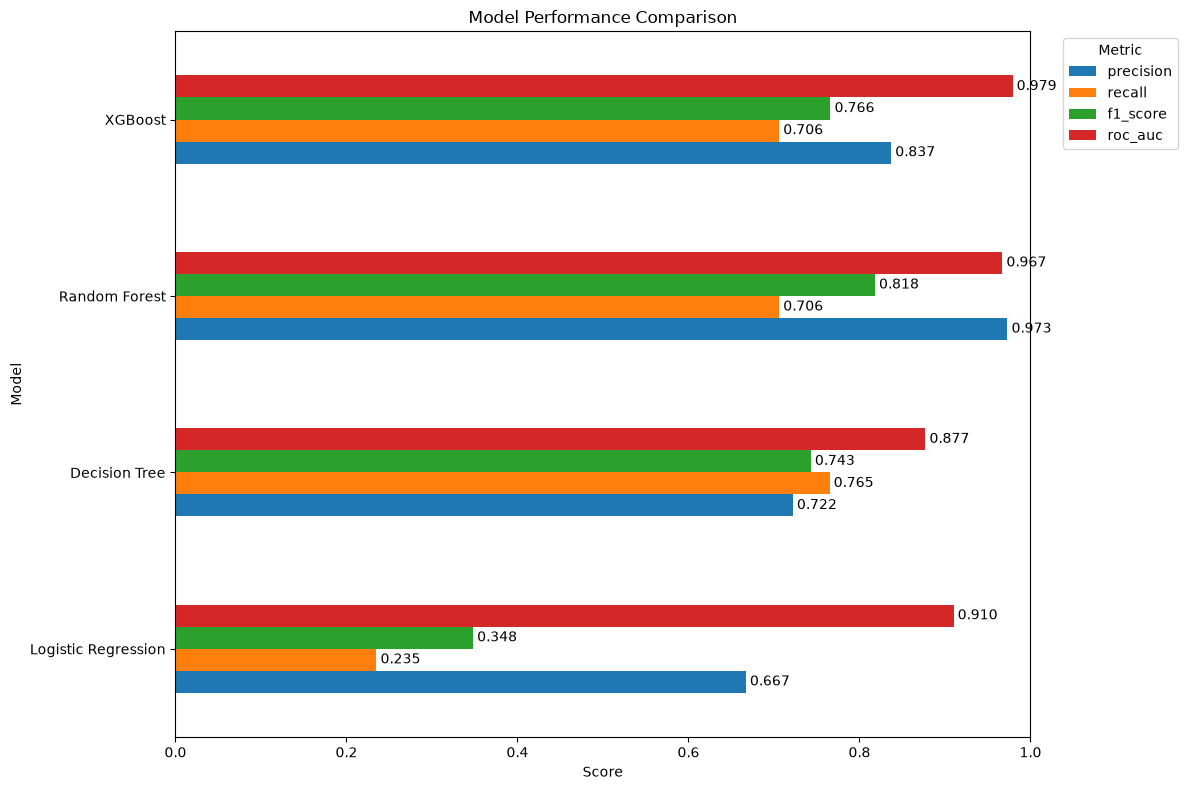

In [48]:
ax = df_result.set_index("model").plot(kind="barh", figsize=(12, 8))


# Loop through each bar to add the value label
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
    

plt.xlabel("Score")
plt.ylabel("Model")
plt.title("Model Performance Comparison")
plt.xlim(0, 1)  # Since all metrics are between 0 and 1
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.03, 1),
    loc="upper left"
)
plt.tight_layout()

plt.show()

# Hyperparameter tuning

## Random forest

In [49]:
rf = RandomForestClassifier(random_state=101, n_jobs=-1)

In [50]:
param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False],
}

In [51]:
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="f1",
    cv=5,
    verbose=1,
    random_state=101,
    n_jobs=-1,
)

In [52]:
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=101)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",101
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns t

In [53]:
rf_search.best_params_

{'n_estimators': 500,
 'min_samples_split': 10,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': None,
 'bootstrap': False}

In [54]:
rf_search.best_score_

np.float64(0.8280237311293707)

In [55]:
best_rf = rf_search.best_estimator_

In [56]:
p_s, r_s, f1_s, roc_auc = evaluate_model(best_rf, X_train, y_train, X_val, y_val)

train data
------------------
[[6761    1]
 [  11  226]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6762
           1       1.00      0.95      0.97       237

    accuracy                           1.00      6999
   macro avg       1.00      0.98      0.99      6999
weighted avg       1.00      1.00      1.00      6999

---------------------------------------------------------

test data
------------------
[[1448    2]
 [  14   37]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1450
           1       0.95      0.73      0.82        51

    accuracy                           0.99      1501
   macro avg       0.97      0.86      0.91      1501
weighted avg       0.99      0.99      0.99      1501

---------------------------------------------------------
ROC-AUC: 0.9699459093982421


In [57]:
df_result = pd.concat([df_result, pd.DataFrame({"model":["Random Forest h_tune"], "precision":[p_s], "recall":[r_s], "f1_score":[f1_s], "roc_auc":[roc_auc]})], ignore_index=True)

## Xgboost

In [58]:
xgb = XGBClassifier(random_state=101, n_jobs=-1)

In [59]:
param_grid_xgb = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

In [60]:
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=30,
    scoring="f1",
    cv=5,
    verbose=1,
    random_state=101,
    n_jobs=-1,
)

In [61]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",101
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [62]:
xgb_search.best_params_

{'subsample': 1.0,
 'n_estimators': 100,
 'max_depth': 6,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [63]:
xgb_search.best_score_

np.float64(0.7932176842300673)

In [64]:
best_xgb = xgb_search.best_estimator_

In [65]:
p_s, r_s, f1_s, roc_auc = evaluate_model(best_xgb, X_train, y_train, X_val, y_val)

train data
------------------
[[6762    0]
 [  29  208]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6762
           1       1.00      0.88      0.93       237

    accuracy                           1.00      6999
   macro avg       1.00      0.94      0.97      6999
weighted avg       1.00      1.00      1.00      6999

---------------------------------------------------------

test data
------------------
[[1447    3]
 [  13   38]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1450
           1       0.93      0.75      0.83        51

    accuracy                           0.99      1501
   macro avg       0.96      0.87      0.91      1501
weighted avg       0.99      0.99      0.99      1501

---------------------------------------------------------
ROC-AUC: 0.9835158891142664


In [66]:
df_result = pd.concat([df_result, pd.DataFrame({"model":["XGBoost h_tune"], "precision":[p_s], "recall":[r_s], "f1_score":[f1_s], "roc_auc":[roc_auc]})], ignore_index=True)

## Tuned model comparison

In [67]:
df_result = df_result.round(3)

In [68]:
print(df_result)

                  model  precision  recall  f1_score  roc_auc
0   Logistic Regression      0.667   0.235     0.348    0.910
1         Decision Tree      0.722   0.765     0.743    0.877
2         Random Forest      0.973   0.706     0.818    0.967
3               XGBoost      0.837   0.706     0.766    0.979
4  Random Forest h_tune      0.949   0.725     0.822    0.970
5        XGBoost h_tune      0.927   0.745     0.826    0.984


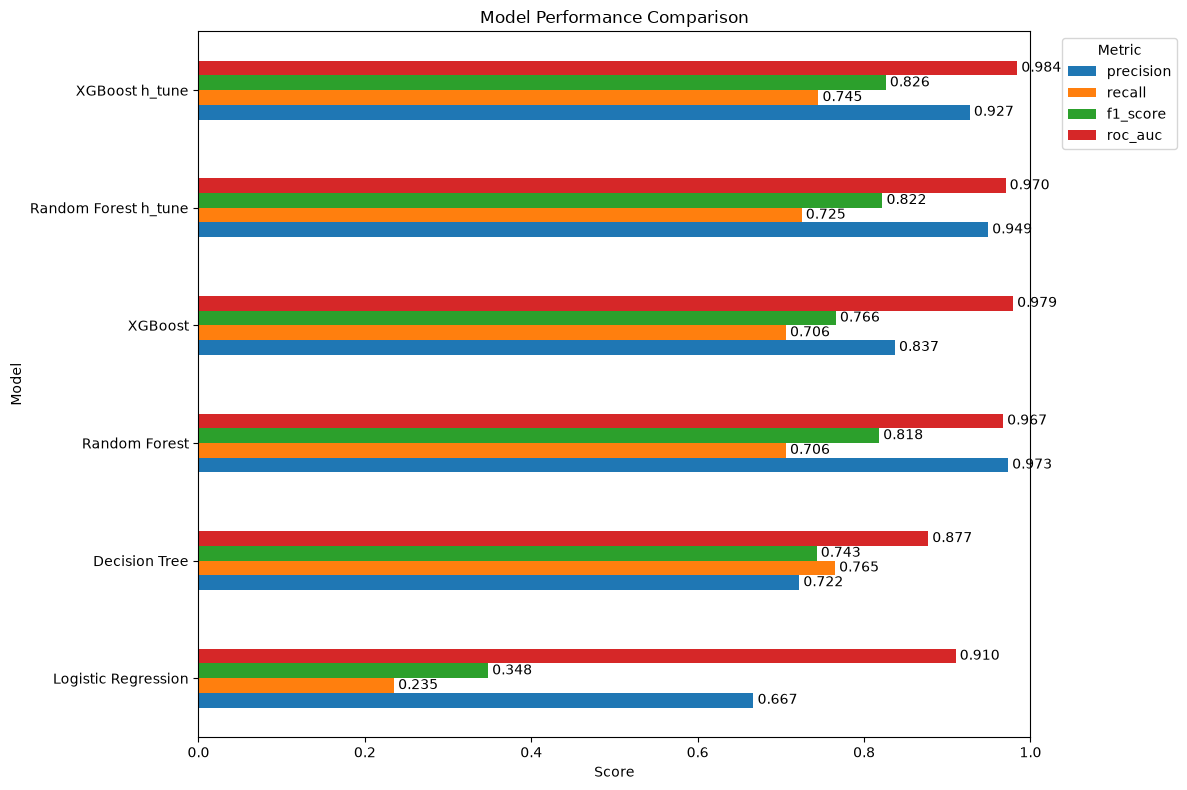

In [69]:
ax = df_result.set_index("model").plot(kind="barh", figsize=(12, 8))


# Loop through each bar to add the value label
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
    

plt.xlabel("Score")
plt.ylabel("Model")
plt.title("Model Performance Comparison")
plt.xlim(0, 1)  # Since all metrics are between 0 and 1
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.03, 1),
    loc="upper left"
)
plt.tight_layout()

plt.show()

Although the tuned Random Forest achieved slightly higher precision (0.949), the tuned XGBoost produced the highest recall (0.745), F1-score (0.826), and ROC-AUC (0.984). Because predictive maintenance prioritizes detecting failures while maintaining strong overall discrimination, XGBoost was selected as the final model.

## Threshold optimization

In [70]:
y_prob = best_xgb.predict_proba(X_val)[:, 1]

In [71]:
thresholds = np.arange(0.1, 0.95, 0.05)

In [72]:
results = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    results.append({
        "threshold": t,
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "f1": f1_score(y_val, y_pred),
    })

In [73]:
threshold_df = pd.DataFrame(results)

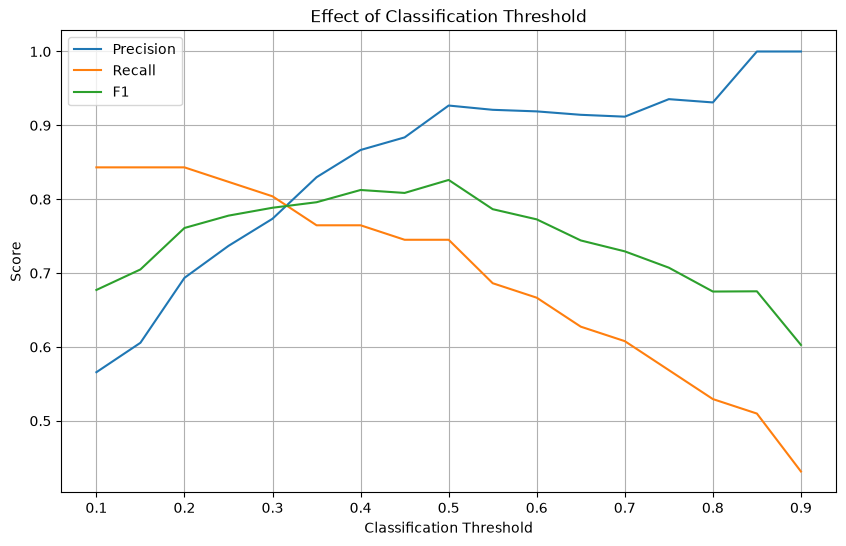

In [74]:
plt.figure(figsize=(10, 6))

plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Effect of Classification Threshold")
plt.grid(True)
plt.legend()

plt.show()

In [75]:
best = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best

threshold    0.500000
precision    0.926829
recall       0.745098
f1           0.826087
Name: 8, dtype: float64

The threshold optimization was performed on the validation set only to avoid introducing bias into the final test evaluation

Classification thresholds from 0.10 to 0.90 were evaluated on the validation set to determine the optimal balance between precision and recall. The highest F1-score was achieved at a threshold of 0.50, indicating that the default decision threshold already provides the best trade-off for the tuned XGBoost model. Therefore, the default threshold was retained for the final model.

# Feature Importance

## Xgboost feature importance

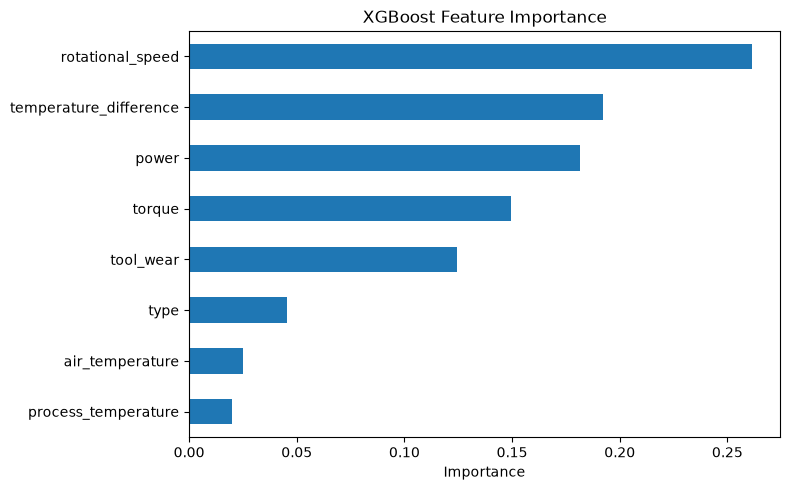

In [76]:
importance = (
    pd.Series(
        best_xgb.feature_importances_,
        index=X_train.columns
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The tuned XGBoost identified rotational speed, power, and the engineered temperature difference feature as the most influential predictors of machine failure. This indicates that mechanical load and thermal conditions are key factors in predicting failures. Interestingly, the original air and process temperatures individually contributed little, while their difference proved highly informative, demonstrating the value of feature engineering. The machine Type feature had minimal importance, suggesting that operating conditions are more predictive than the machine category itself.

## Permutation importance

<Axes: title={'center': 'XGBoost Permutation Importance'}>

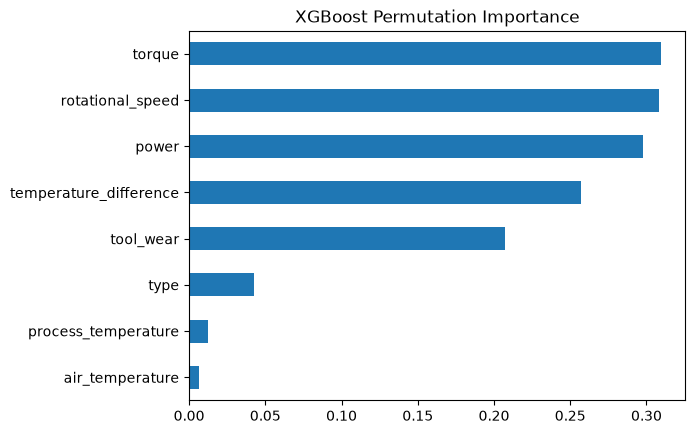

In [77]:
result = permutation_importance(
    best_xgb,
    X_val,
    y_val,
    n_repeats=20,
    random_state=101,
    scoring="f1",
)

importance = (
    pd.Series(result.importances_mean, index=X_val.columns)
    .sort_values()
)
plt.title("XGBoost Feature Importance")

importance.plot(kind="barh", title="XGBoost Permutation Importance")

To validate the model-specific feature importance, permutation importance was computed on the validation set. The analysis confirmed that torque, rotational speed, power, temperature difference, and tool wear are the dominant predictors of machine failure. The engineered features (power and temperature_difference) remained among the most influential variables, demonstrating that feature engineering improved the model's predictive capability. In contrast, the original air and process temperatures contributed little individually, indicating that their relationship is more informative than their absolute values.

# Final model

After selecting XGBoost as the best-performing model, the training and validation datasets are combined to maximize the amount of data available for learning. The final model will then retrained using the optimized hyperparameters before being evaluated once on the untouched test set.

In [78]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

In [79]:
best_xgb.fit(X_train_final, y_train_final)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [80]:
evaluate_model(best_xgb, X_train_final, y_train_final, X_test, y_test)

train data
------------------
[[8211    1]
 [  38  250]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      8212
           1       1.00      0.87      0.93       288

    accuracy                           1.00      8500
   macro avg       1.00      0.93      0.96      8500
weighted avg       1.00      1.00      1.00      8500

---------------------------------------------------------

test data
------------------
[[1442    7]
 [  18   33]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1449
           1       0.82      0.65      0.73        51

    accuracy                           0.98      1500
   macro avg       0.91      0.82      0.86      1500
weighted avg       0.98      0.98      0.98      1500

---------------------------------------------------------
ROC-AUC: 0.989648033126294


(0.825, 0.6470588235294118, 0.7252747252747253, 0.989648033126294)

The target variable is imbalanced, with machine failures representing approximately 3–4% of the observations. To address this, stratified sampling was used during data splitting, and evaluation focused on precision, recall, F1-score, and ROC-AUC rather than accuracy alone. Threshold optimization was also performed to improve the balance between precision and recall. More advanced approaches such as class weighting or synthetic oversampling (e.g., SMOTE) are left as future work.

In [81]:
artifacts = {
    "preprocessor": encoder,
    "model": best_xgb,
    "feature_names": X_train_final.columns.to_list()
}

save_model(artifacts, Path("../models/model_artifacts.pkl"))

This project developed an end-to-end predictive maintenance system using the AI4I 2020 Predictive Maintenance dataset. After comparing multiple machine learning algorithms, a tuned XGBoost classifier was selected as the final model based on its superior Recall, F1-score, and ROC-AUC. Feature engineering, hyperparameter tuning, threshold optimization, and model interpretation were performed to improve predictive performance and understand the factors influencing machine failures. The trained model will be deployed through a FastAPI application to provide real-time failure predictions.